In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pickle

### Data Loading and Preprocessing

We will define transformations for the training and validation sets, load the dataset using `ImageFolder`, and create data loaders. The dataset is located at the `path` variable obtained from `kagglehub.dataset_download`.

In [16]:
import os
from torch.utils.data import random_split

data_dir = os.path.join(path, 'plantvillage dataset', 'color')

# Define transforms for training and validation
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load the entire dataset using ImageFolder
full_dataset = datasets.ImageFolder(data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)

# Split into 80% train and 20% validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

# Assign corresponding transforms to the subsets
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            # Need to get raw image for transforms which expect PIL images, but subset returns PIL because ImageFolder hasn't transformed it yet
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_data = TransformedSubset(train_data, transform=train_transforms)
val_data = TransformedSubset(val_data, transform=val_transforms)

# Define the dataloaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

print(f"Total images found: {len(full_dataset)}")
print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of classes: {num_classes}")

Total images found: 54305
Number of training samples: 43444
Number of validation samples: 10861
Number of classes: 38


In [15]:
import os

print(f"Contents of {path}:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
        # List contents of the 'plantvillage dataset' folder if it exists
        if item == 'plantvillage dataset':
            pv_dataset_path = item_path
            for sub_item in os.listdir(pv_dataset_path):
                sub_item_path = os.path.join(pv_dataset_path, sub_item)
                if os.path.isdir(sub_item_path):
                    print(f"    [SUBDIR] {sub_item}")
                    # If 'color' directory found, list its contents
                    if sub_item == 'color':
                        color_path = sub_item_path
                        print(f"      Contents of {color_path}:")
                        for color_content in os.listdir(color_path):
                            color_content_path = os.path.join(color_path, color_content)
                            if os.path.isdir(color_content_path):
                                print(f"        [DIR] {color_content}")
                            else:
                                print(f"        [FILE] {color_content}")
                else:
                    print(f"    [FILE] {sub_item}")
    else:
        print(f"  [FILE] {item}")

Contents of /kaggle/input/plantvillage-dataset:
  [DIR] plantvillage dataset
    [SUBDIR] segmented
    [SUBDIR] grayscale
    [SUBDIR] color
      Contents of /kaggle/input/plantvillage-dataset/plantvillage dataset/color:
        [DIR] Tomato___Late_blight
        [DIR] Tomato___healthy
        [DIR] Grape___healthy
        [DIR] Orange___Haunglongbing_(Citrus_greening)
        [DIR] Soybean___healthy
        [DIR] Squash___Powdery_mildew
        [DIR] Potato___healthy
        [DIR] Corn_(maize)___Northern_Leaf_Blight
        [DIR] Tomato___Early_blight
        [DIR] Tomato___Septoria_leaf_spot
        [DIR] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
        [DIR] Strawberry___Leaf_scorch
        [DIR] Peach___healthy
        [DIR] Apple___Apple_scab
        [DIR] Tomato___Tomato_Yellow_Leaf_Curl_Virus
        [DIR] Tomato___Bacterial_spot
        [DIR] Apple___Black_rot
        [DIR] Blueberry___healthy
        [DIR] Cherry_(including_sour)___Powdery_mildew
        [DIR] Peac

### Model Definition

We will use a pre-trained ResNet18 model from torchvision, modify its final fully connected layer to match the number of classes in our dataset, and then move the model to the GPU if available.

In [17]:
# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load a pre-trained ResNet18 model
model = models.resnet18(pretrained=True)

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer with a new one for our number of classes
# The number of input features to the fc layer will be `model.fc.in_features`
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move the model to the chosen device
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print(model)

Using device: cuda


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Training

Now, we will train the model. We'll track the training and validation loss and accuracy to generate training curves, and save the best model weights.

In [18]:
epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_data)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_data)
    epoch_val_accuracy = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} - "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

    # Save the best model
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(model.state_dict(), 'plantvillage_model_weights.pth')
        print(f"Saved best model weights with Val Acc: {best_val_accuracy:.4f}")

print("Training complete.")

Epoch 1/10 - Train Loss: 0.9902, Train Acc: 0.7490 - Val Loss: 0.3361, Val Acc: 0.9065
Saved best model weights with Val Acc: 0.9065
Epoch 2/10 - Train Loss: 0.5561, Train Acc: 0.8396 - Val Loss: 0.2951, Val Acc: 0.9094
Saved best model weights with Val Acc: 0.9094
Epoch 3/10 - Train Loss: 0.4887, Train Acc: 0.8519 - Val Loss: 0.2591, Val Acc: 0.9181
Saved best model weights with Val Acc: 0.9181
Epoch 4/10 - Train Loss: 0.4608, Train Acc: 0.8598 - Val Loss: 0.2598, Val Acc: 0.9163
Epoch 5/10 - Train Loss: 0.4412, Train Acc: 0.8639 - Val Loss: 0.2241, Val Acc: 0.9267
Saved best model weights with Val Acc: 0.9267
Epoch 6/10 - Train Loss: 0.4331, Train Acc: 0.8663 - Val Loss: 0.2710, Val Acc: 0.9079
Epoch 7/10 - Train Loss: 0.4253, Train Acc: 0.8686 - Val Loss: 0.2427, Val Acc: 0.9221
Epoch 8/10 - Train Loss: 0.4140, Train Acc: 0.8708 - Val Loss: 0.2219, Val Acc: 0.9267
Epoch 9/10 - Train Loss: 0.4215, Train Acc: 0.8690 - Val Loss: 0.2153, Val Acc: 0.9274
Saved best model weights with Val

### Plotting Training Curves

We will visualize the training and validation loss and accuracy over epochs.

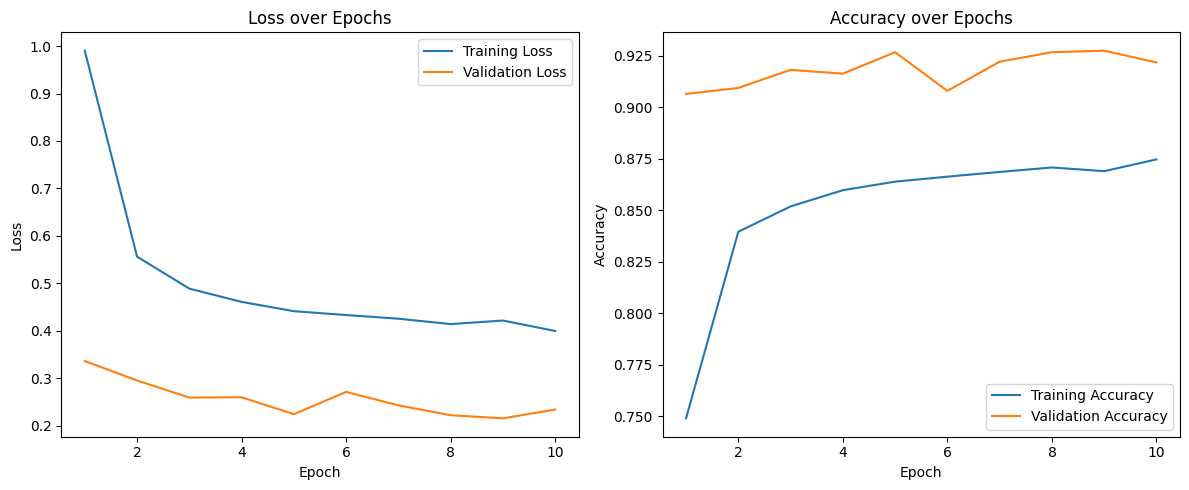

In [19]:
# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluation and Confusion Matrix

We will evaluate the model on the validation set and generate a confusion matrix and classification report.

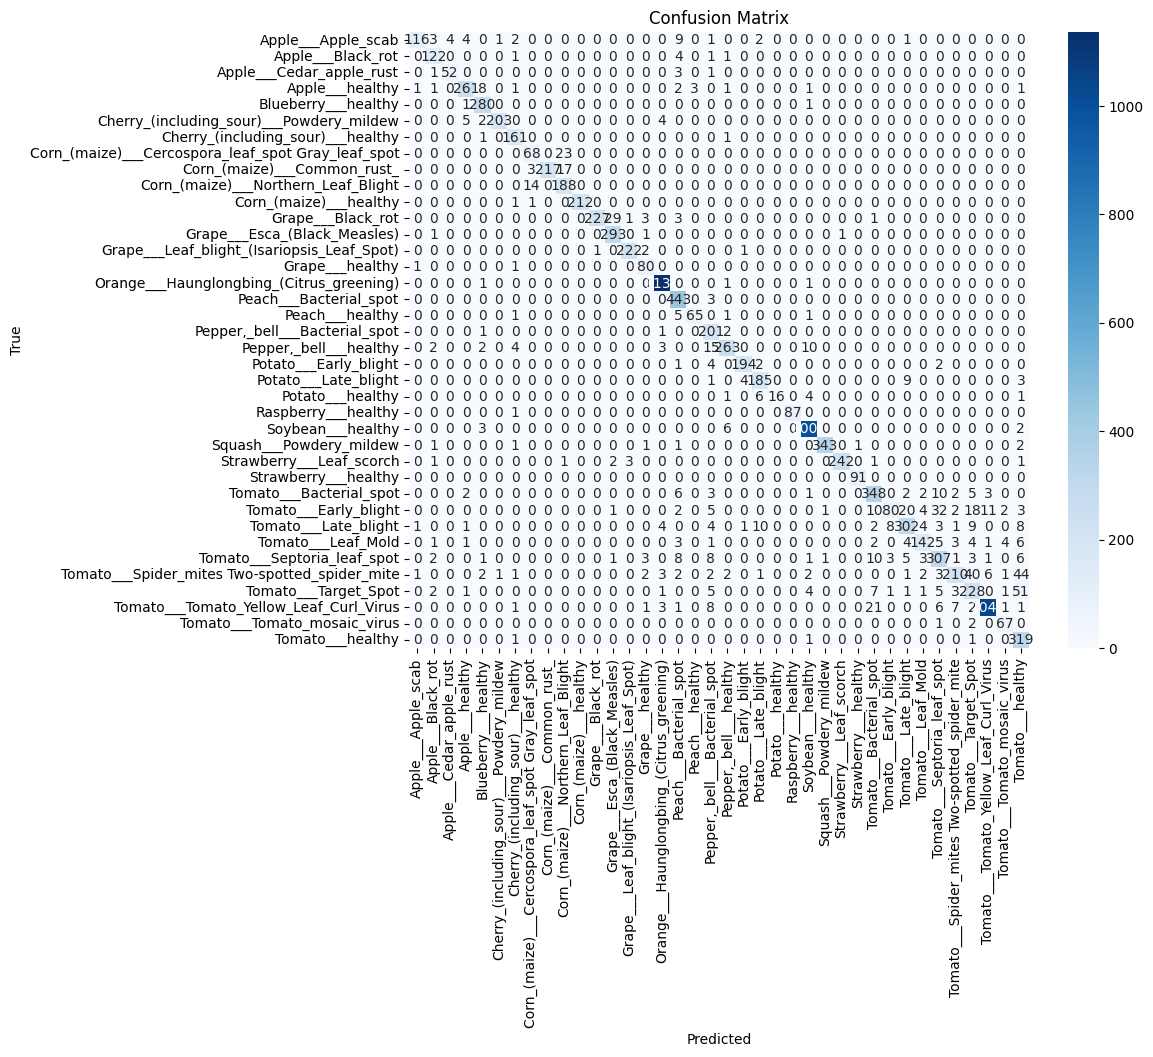

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.81      0.88       143
                                 Apple___Black_rot       0.89      0.95      0.92       129
                          Apple___Cedar_apple_rust       0.93      0.91      0.92        57
                                   Apple___healthy       0.95      0.93      0.94       280
                               Blueberry___healthy       0.93      0.99      0.96       282
          Cherry_(including_sour)___Powdery_mildew       0.99      0.95      0.97       214
                 Cherry_(including_sour)___healthy       0.91      0.99      0.95       163
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.75      0.77        91
                       Corn_(maize)___Common_rust_       1.00      0.92      0.96       237
               Corn_(maize)___Northern_Leaf_Blight      

In [20]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
from sklearn.metrics import classification_report
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:")
print(report)

### Saving the Model

Finally, we will save the entire model as a `.pkl` file and the model weights as a `.pth` file, as requested.

In [22]:
# Save the entire model as .pkl (Python pickle file)
with open('plantvillage_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as plantvillage_model.pkl")

# The weights were already saved as 'plantvillage_model_weights.pth' during training
print("Model weights saved as plantvillage_model_weights.pth during training.")

Model saved as plantvillage_model.pkl
Model weights saved as plantvillage_model_weights.pth during training.
